In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import box, LineString
import xarray as xr
import os

import matplotlib.cm as cm
import matplotlib.colors as colors
from matplotlib.patches import Patch
%matplotlib inline
#%matplotlib qt

In [ ]:



interpretations_path = Path(r"C:\Users\satuki\Downloads\interpretations-20260527T155259.zip")
# Read into a GeoDataFrame
gdf = gpd.read_file(interpretations_path)

# Keep only rows where kind is firn_ice_interface
gdf = gdf[gdf["kind"] == "firn_ice_interface"]

gdf = gdf[~gdf["radar_key"].isin([
    "austfonna-profile-2011-800MHz-mala-26"
])]

transect = LineString(gdf.query("radar_key == 'austfonna-profile-2011-800MHz-mala-05'")["geometry"])

# Define a bounding box (minx, miny, maxx, maxy)
#bbox = box(666000,  8876916, 671000,  8882658)
bbox = box(*transect.buffer(100).bounds)
# Keep only points that belong to the bounding box
filtered_gdf = gdf[gdf.intersects(bbox)].copy()


# Convert twtt to numeric values (invalid values become NaN)
filtered_gdf["twtt"] = pd.to_numeric(filtered_gdf["twtt"], errors="coerce")
# Convert year to numeric for color mapping
filtered_gdf["year"] = pd.to_numeric(filtered_gdf["year"], errors="coerce")


# Distance from point → transect
filtered_gdf["dist_to_line"] = filtered_gdf.geometry.distance(transect)

# Keep only nearby points (tune this!)
filtered_gdf = filtered_gdf[filtered_gdf["dist_to_line"] < 50]

# Project points → distance along transect
filtered_gdf["dist_along"] = filtered_gdf.geometry.apply(transect.project)

# Save filtered points
filtered_gdf.to_file("filtered_points_tmp2.geojson")





In [88]:
timeseries_locs = [(10000, "blue"), (13000, "green"), (16000, "purple")]
timeseries_avg_width = 500

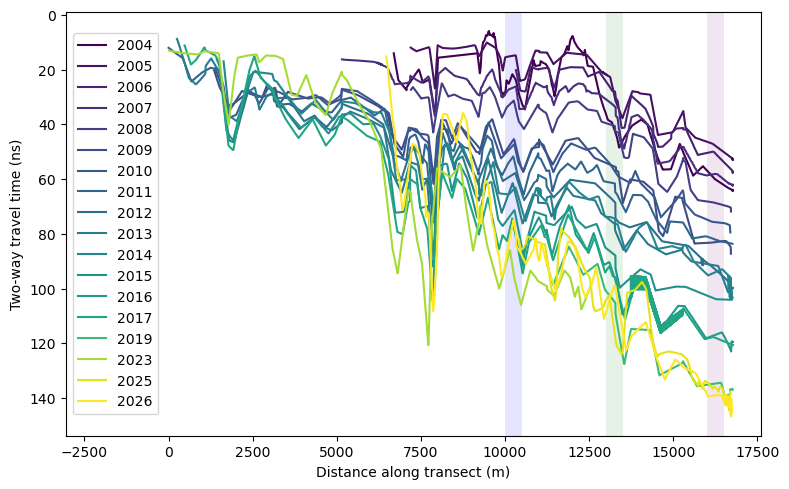

In [ ]:
# Create a colormap mapper
mappable = cm.ScalarMappable(
    norm=colors.Normalize(vmin=filtered_gdf["year"].min(), vmax=filtered_gdf["year"].max()),
    #norm=colors.Normalize(vmin=2008, vmax=2012),
    cmap="viridis"
)

plt.figure(figsize=(8, 5))
# Loop through each year
for year, data in filtered_gdf.groupby("year"):

    # Sort points along profile direction (easting)
    #data = data.sort_values("easting")
    data = data.sort_values("dist_along")

    # Collapse multiple points → single profile
    #data = data.groupby("dist_along", as_index=False)["twtt"].median()

    # Filter out subsequent points that have the same value (avoids blockiness)
    data = data[np.abs(np.diff(data["twtt"], prepend=[0])) > 0]
    # Plot line (easting vs twtt) for that year
    sc = plt.plot(
        data["dist_along"],
        data["twtt"],
        color=mappable.to_rgba(float(year)),
        label=year,
    )
    # Plot the year
    #last_point = data.sort_values("dist_along").iloc[-1]
    #plt.annotate(year, (last_point["dist_along"], last_point["twtt"]), fontsize=8)

ylim = plt.gca().get_ylim()[::-1]
plt.ylim(ylim)

for timeseries_min_loc, color in timeseries_locs:
    plt.fill_between(
        x=[timeseries_min_loc, timeseries_min_loc + timeseries_avg_width],
        y1=[ylim[0]] * 2,
        y2=[ylim[1]] * 2,
        color=color,
        alpha=0.1,
        edgecolor="none",
    )

#cbar = plt.colorbar(mappable, cax=plt.gca())
#cbar.set_label("Year")
xlim = plt.gca().get_xlim()
plt.xlim(xlim[0] - (xlim[1] - xlim[0]) * 0.12, xlim[1])
#plt.xlim(12500, xlim[1])
#plt.ylim(130, 90)
plt.legend(loc="center left")
plt.xlabel("Distance along transect (m)")
plt.ylabel("Two-way travel time (ns)")
plt.title("")
plt.tight_layout()
#plt.gca().invert_yaxis() #
#plt.savefig("Austfonna_firn_change_track_to_coreF.png")
plt.show()


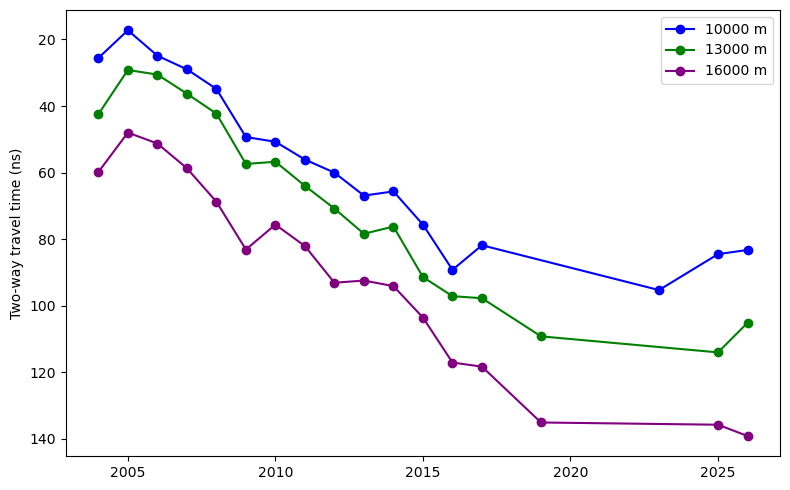

In [100]:


fig = plt.figure(figsize=(8, 5), dpi=100)
ax = plt.gca()


for i, (timeseries_min_loc, color) in enumerate(timeseries_locs):
        years = []
        twtts = []

        for year, data in filtered_gdf.groupby("year"):
                subset = data[(data["dist_along"] > timeseries_min_loc) & (data["dist_along"] < (timeseries_min_loc + timeseries_avg_width))]
                if subset.shape[0] == 0:
                        continue

                twtts.append(subset["twtt"].mean())
                years.append(year)
        
        ax.plot(years, twtts, color=color, label=f"{timeseries_min_loc} m", marker="o")

ax.set_ylim(ax.get_ylim()[::-1])
plt.ylabel("Two-way travel time (ns)")
ax.legend()
plt.tight_layout()
plt.savefig("zoomed_in_time_series_Austfonna.png")
plt.show()


In [ ]:
twtt = gdf["twtt"]                 
easting = gdf["easting"]              
northing = gdf["northing"]          
distance = gdf["distance"]         
year = gdf["year"]                  
kind = gdf["kind"]

bbox = box(669536, 8879242, 669675, 8879341)
filtered_gdf = gdf[gdf.intersects(bbox)].copy()


filtered_gdf["twtt"] = pd.to_numeric(filtered_gdf["twtt"], errors="coerce")
filtered_gdf["year_num"] = pd.to_numeric(filtered_gdf["year"], errors="coerce")


norm = colors.Normalize(vmin=filtered_gdf["year_num"].min(), vmax=filtered_gdf["year_num"].max())
cmap = cm.viridis

mappable = cm.ScalarMappable(norm=norm, cmap=cmap)
mappable.set_array([])

plt.figure(figsize=(8, 5))
for year, data in filtered_gdf.groupby("year"):
    sc = plt.plot(
        data["easting"],
        data["twtt"],
        color=mappable.to_rgba(float(year)),
        #cmap="viridis",
        #s=18,
        #edgecolor="none"
        label=year,
    )

#cbar = plt.colorbar(mappable, cax=plt.gca())
#cbar.set_label("Year")
plt.legend()
plt.xlabel("Easting (m)")
plt.ylabel("twtt")
plt.title("")
plt.tight_layout()
plt.gca().invert_yaxis() #
plt.show()



## Example radargram firn-ice interface

In [ ]:
import level2_processing

filepath = "../processed/level2/austfonna/austfonna-profile-2026-800MHz-mala-06/austfonna-profile-2026-800MHz-mala-06.nc"

with xr.open_dataset(filepath) as dataset:
    dataset = dataset.sel(x=slice(100, 2000))

    plt.figure(figsize=(5, 3))
    plt.imshow(
        level2_processing.normalize(dataset.data),
        extent=(
            0,
            dataset["distance"].max() - dataset["distance"].min(),
            #dataset["x"].min(),
            #dataset["x"].max(),
            dataset["twtt"].max(),
            dataset["twtt"].min()
        ),
        cmap="Greys_r",
        aspect="auto",
    )
    ylim=(100,0)
    plt.ylim(ylim)

plt.xlabel("Distance (m)")
plt.ylabel("Two-way travel time (ns)")

plt.show()
#plt.savefig("example_firn_ice_2026.png")
    

## Core + radargram

In [54]:
filepath = r'C:\Users\satuki\svalbard_pfa'
names = ['Eton-5-6']
cores = dict()
ice = dict()

for nn in range(len(names)):
    name = names[nn]

    # Density file
    filenamecore = os.path.join(filepath, f'Density_{name}_26.csv')
    cores[name] = pd.read_csv(filenamecore, header=5, sep=';')
    cores[name].columns = cores[name].columns.str.strip()

    # Ice layer file
    filenameice = os.path.join(filepath, f'Icelayer_{name}_26.csv')
    ice[name] = pd.read_csv(filenameice, header=5, sep=';')
    ice[name].columns = ice[name].columns.str.strip()

fontsize = 10
plt.rcParams['font.size'] = fontsize
cyan=(111/256, 231/256, 219/256)
yell=(222/256, 181/256, 106/256)

name = names[0]  # or directly: name = 'Eton-5-6'
core = cores[name]
icelayer = ice[name]

dens = []
depth = []

# Build density profile
if (core['Facies'] != 'S').any():
    for ii in range(len(core)):
        depth.append(core['Start (m)'][ii])
        depth.append(core['End (m)'][ii])
        dens.append(core['Density corrected (kg/m3)'][ii])
        dens.append(core['Density corrected (kg/m3)'][ii])

dens = np.array(dens)

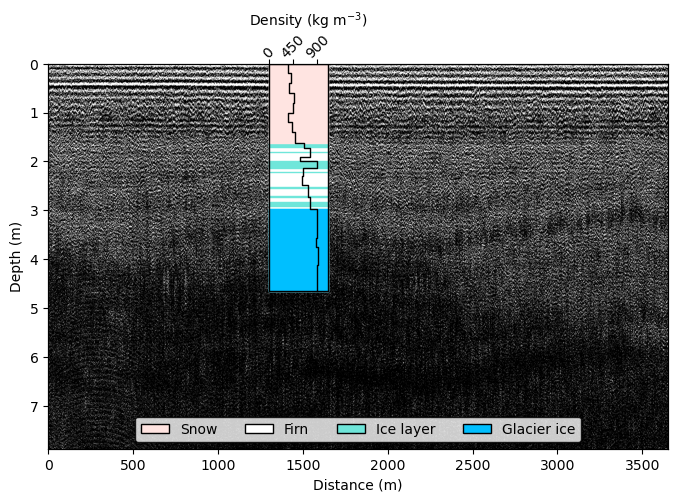

In [71]:
import level2_processing

filepath = "../processed/level2/austfonna/austfonna-profile-2026-800MHz-mala-06/austfonna-profile-2026-800MHz-mala-06.nc"

import numpy as np
import matplotlib.pyplot as plt


def twtt_to_depth(twtt, t_break=13.0, v1=0.23, v2=0.180):
    twtt = np.asarray(twtt)
    return np.where(
        twtt <= t_break,
        0.5 * v1 * twtt,
        0.5 * v1 * t_break + 0.5 * v2 * (twtt - t_break),
    )


def warp_to_depth(da, x_dim="x", y_dim="y", twtt_coord="twtt", depth=None):
    da = da.transpose(y_dim, x_dim)
    twtt = da[twtt_coord].values
    depth_in = twtt_to_depth(twtt)

    if depth is None:
        depth = np.linspace(depth_in.min(), depth_in.max(), len(depth_in))

    data_out = np.empty((len(depth), da.sizes[x_dim]), dtype=float)
    for i in range(da.sizes[x_dim]):
        data_out[:, i] = np.interp(depth, depth_in, da[:, i].values, left=np.nan, right=np.nan)

    return xr.DataArray(
        data_out,
        dims=("depth", x_dim),
        coords={"depth": depth, x_dim: da[x_dim].values},
        name=da.name,
    )


with xr.open_dataset(filepath) as dataset:
    dataset = dataset.sel(x=slice(100, 2000), y=slice(0, 800))
    
    radar_depth = warp_to_depth(
        dataset["data"],
        x_dim="x",
        y_dim="y",
        twtt_coord="twtt",
    )

    plt.figure(figsize=(8, 5))
    plt.imshow(
        level2_processing.normalize(radar_depth.values),
        cmap="Greys_r",
        aspect="auto",
        extent=[
            0,
            dataset["distance"].max() - dataset["distance"].min(),
            radar_depth["depth"].values.max(),
            radar_depth["depth"].values.min(),
        ],
        vmin=0,
        vmax=150,
    )
    core_loc = (1300, 1650)
    plt.fill_between(core_loc, 0, max(icelayer['End (m)']), color="white")
    for zz in range(len(icelayer)):
        plt.fill_between(core_loc,
                        icelayer['Start (m)'][zz],
                        icelayer['End (m)'][zz],
                        color=cyan)

    # Snow
    plt.fill_between(core_loc,
                    core['Start (m)'][0],
                    core['End (m)'][len(core[core['Facies'] == 'S'])-1],
                    color='mistyrose')

    # Fill the bottom ice lens with a different (ice) color
    plt.fill_between(core_loc, max(icelayer['Start (m)']), max(icelayer['End (m)']), color="deepskyblue")
    # Make a frame around core
    plt.fill_between(core_loc, 0, max(icelayer['End (m)']), facecolor="none", edgecolor="black", linewidth=1)



    # Density curve
    density_scale = 1100
    plt.plot((core_loc[1] - core_loc[0]) * dens / density_scale + core_loc[0], depth, 'k', linewidth=1)

    ax = plt.gca()
    ax2 = plt.twiny()

    ax2.set_xlim(ax.get_xlim())

    ticks = np.array([0, 450, 900])
    ax2.set_xticks((core_loc[1] - core_loc[0]) * ticks / density_scale + core_loc[0])
    ax2.set_xticklabels(ticks, rotation=45)
    ax2.tick_params(axis='x', which='major', pad=-1)
    ax2.set_xlabel("Density (kg m$^{-3}$)")
    ax2.xaxis.set_label_coords(0.42, 1.1) 




ax.set_xlabel("Distance (m)")
ax.set_ylabel("Depth (m)")

# Legend (same as before)
legend_elements = [
    Patch(facecolor='mistyrose', edgecolor='k', label='Snow'),
    Patch(facecolor='white', edgecolor='k', label='Firn'),
    Patch(facecolor=cyan, edgecolor='k', label='Ice layer'),
    Patch(facecolor='deepskyblue', edgecolor='k', label='Glacier ice'),
    #Patch(facecolor='dimgrey', edgecolor='k', label='No data')
]

plt.gca().legend(loc='lower center',
          handles=legend_elements,
          edgecolor='k',
          ncol=5,
          fontsize=10)

plt.savefig("example_firn_ice_2026_with_core.png")
    

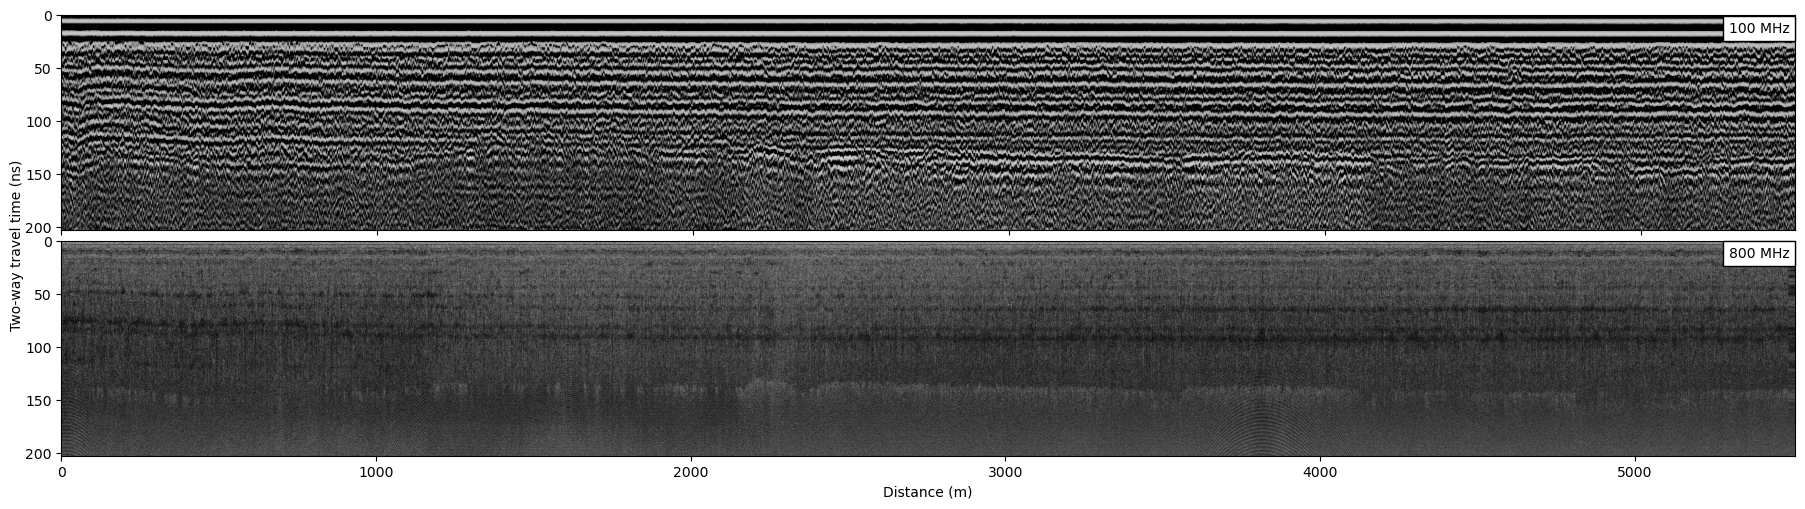

In [ ]:
import level2_processing
attributes = [
    {
        "radar_key": "austfonna-profile-2026-100MHz-mala-05",
        "xlim": (1200, 8340),
        "standstills": [(5757, 5834)],
        "vlim": 350,
        "zoom_vlim": ...,
    },
    {
    "radar_key": "austfonna-profile-2026-800MHz-mala-07",
    "xlim": (4500, 13600),
    "standstills": [(4163, 4284), (6077, 6342), (7826, 8266)],
    "vlim": 150,
    "zoom_vlim": ...,
    },
]
ylim = (203, 0)

fig = plt.figure(figsize=(18, 5))
axes = fig.subplots(2, 1)
max_distances = []
labels = ["100 MHz", "800 MHz"]

for i, attrs in enumerate(attributes):
    ax = axes[i]

    with xr.open_dataset(f"../processed/level2/austfonna/{attrs['radar_key']}/{attrs['radar_key']}.nc") as dataset:
        dataset = dataset.sel(x=slice(attrs["xlim"][0], attrs["xlim"][1]))
        for standstill in attrs["standstills"]:
            standstill_idx = np.arange(standstill[0], standstill[1])
            drop_candidates = standstill_idx[np.isin(standstill_idx, dataset["x"].values)]

            dataset = dataset.drop_sel(x=drop_candidates)
        #axes[2].plot(dataset["easting"], dataset["northing"], label=attrs["radar_key"], alpha=0.5)

        #dataset = dataset.groupby(dataset["distance"].astype(int)).mean()
        max_distance = np.sqrt((dataset["easting"].max() - dataset["easting"].min()) ** 2 + (dataset["northing"].max() - dataset["northing"].min()) ** 2)
        ax.imshow(
            level2_processing.normalize(dataset.data),
            extent=(
                0,
                max_distance,
                #dataset["x"].min(),
                #dataset["x"].max(),
                dataset["twtt"].max(),
                dataset["twtt"].min()
            ),
            cmap="Greys_r",
            aspect="auto",
            vmin=0,
            vmax=attrs["vlim"],
        )
        ax.set_ylim(ylim)
        max_distances.append(max_distance)

        
        ax.text(
        0.997, 0.971,
        labels[i],
        transform=ax.transAxes,
        ha="right", va="top",
        color="black",
        bbox=dict(facecolor="white", edgecolor="black")
        )


plt.tight_layout()
plt.xlabel("Distance (m)")
#fig.supylabel("Two-way travel time (ns)")
fig.text(0, 0.5, "Two-way travel time (ns)", va='center', rotation='vertical')



xticks = axes[1].get_xticks()
axes[0].set_xticks(xticks)
axes[0].set_xticklabels([""] * len(xticks))
axes[0].set_xlim(0, max_distances[0])

fig.subplots_adjust(hspace=0.05)


#plt.savefig("PFA_100Mhz_800MHz.png")
plt.show()

In [126]:
dataset

<xarray.Dataset> Size: 15MB
Dimensions:        (y: 1972, x: 1901)
Coordinates:
  * y              (y) uint32 8kB 0 1 2 3 4 5 ... 1966 1967 1968 1969 1970 1971
    depth          (y) float32 8kB ...
    twtt           (y) float32 8kB 0.0 0.105 0.2099 0.3149 ... 206.7 206.8 206.9
  * x              (x) uint32 8kB 100 101 102 103 104 ... 1997 1998 1999 2000
    distance       (x) float64 15kB 174.5 174.5 174.5 ... 3.827e+03 3.827e+03
    easting        (x) float64 15kB ...
    elevation      (x) float64 15kB ...
    latitude       (x) float64 15kB ...
    longitude      (x) float64 15kB ...
    northing       (x) float64 15kB ...
    time           (x) datetime64[ns] 15kB ...
Data variables:
    data           (y, x) float32 15MB -0.0 -0.0 0.8901 ... -0.2492 -0.2551 0.0
    projected_crs  uint8 1B ...
Attributes: (12/23)
    Conventions:                       CF-1.7
    antenna:                           800 MHz shielded=3
    antenna_separation:                0.14
    antenna_separation_unit:           m
    crs:                               EPSG:32635
    elevation_correction:              None
    ...                                ...
    time_interval_unit:                s
    total_distance:                    9087.253218959331
    total_distance_unit:               m
    vertical_sampling_frequency:       9527.399
    vertical_sampling_frequency_unit:  MHz
    power_fixed:                       1